In [2]:
import pandas as pd

df = pd.read_csv("keystroke.csv")

print(df.head())
print(df.columns)
print(df.info())

  subject  sessionIndex  rep  H.period  DD.period.t  UD.period.t     H.t  \
0    s002             1    1    0.1491       0.3979       0.2488  0.1069   
1    s002             1    2    0.1111       0.3451       0.2340  0.0694   
2    s002             1    3    0.1328       0.2072       0.0744  0.0731   
3    s002             1    4    0.1291       0.2515       0.1224  0.1059   
4    s002             1    5    0.1249       0.2317       0.1068  0.0895   

   DD.t.i  UD.t.i     H.i  ...     H.a  DD.a.n  UD.a.n     H.n  DD.n.l  \
0  0.1674  0.0605  0.1169  ...  0.1349  0.1484  0.0135  0.0932  0.3515   
1  0.1283  0.0589  0.0908  ...  0.1412  0.2558  0.1146  0.1146  0.2642   
2  0.1291  0.0560  0.0821  ...  0.1621  0.2332  0.0711  0.1172  0.2705   
3  0.2495  0.1436  0.1040  ...  0.1457  0.1629  0.0172  0.0866  0.2341   
4  0.1676  0.0781  0.0903  ...  0.1312  0.1582  0.0270  0.0884  0.2517   

   UD.n.l     H.l  DD.l.Return  UD.l.Return  H.Return  
0  0.2583  0.1338       0.3509       0.217

In [23]:
print(df.shape)

(20400, 33)


In [24]:
print(len(df))

20400


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 33 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   H.period         20400 non-null  float64
 1   DD.period.t      20400 non-null  float64
 2   UD.period.t      20400 non-null  float64
 3   H.t              20400 non-null  float64
 4   DD.t.i           20400 non-null  float64
 5   UD.t.i           20400 non-null  float64
 6   H.i              20400 non-null  float64
 7   DD.i.e           20400 non-null  float64
 8   UD.i.e           20400 non-null  float64
 9   H.e              20400 non-null  float64
 10  DD.e.five        20400 non-null  float64
 11  UD.e.five        20400 non-null  float64
 12  H.five           20400 non-null  float64
 13  DD.five.Shift.r  20400 non-null  float64
 14  UD.five.Shift.r  20400 non-null  float64
 15  H.Shift.r        20400 non-null  float64
 16  DD.Shift.r.o     20400 non-null  float64
 17  UD.Shift.r.o

In [27]:
print(df.describe()) 

           H.period   DD.period.t   UD.period.t           H.t        DD.t.i  \
count  20400.000000  20400.000000  20400.000000  20400.000000  20400.000000   
mean       0.093379      0.264148      0.170769      0.085727      0.169085   
std        0.029626      0.220534      0.226836      0.027424      0.123546   
min        0.001400      0.018700     -0.235800      0.009300      0.001100   
25%        0.074400      0.146900      0.049800      0.066000      0.113600   
50%        0.089500      0.205950      0.108700      0.081000      0.140400   
75%        0.107900      0.306450      0.212400      0.099800      0.183900   
max        0.376100     12.506100     12.451700      0.241100      4.919700   

             UD.t.i           H.i        DD.i.e        UD.i.e           H.e  \
count  20400.000000  20400.000000  20400.000000  20400.000000  20400.000000   
mean       0.083358      0.081565      0.159372      0.077806      0.089138   
std        0.125755      0.026887      0.226928    

In [3]:
df = df.drop(['subject', 'sessionIndex', 'rep'], axis=1) #remove unnessary columns

In [4]:
print(df.isnull().sum()) # handle missing values

df = df.dropna()

H.period           0
DD.period.t        0
UD.period.t        0
H.t                0
DD.t.i             0
UD.t.i             0
H.i                0
DD.i.e             0
UD.i.e             0
H.e                0
DD.e.five          0
UD.e.five          0
H.five             0
DD.five.Shift.r    0
UD.five.Shift.r    0
H.Shift.r          0
DD.Shift.r.o       0
UD.Shift.r.o       0
H.o                0
DD.o.a             0
UD.o.a             0
H.a                0
DD.a.n             0
UD.a.n             0
H.n                0
DD.n.l             0
UD.n.l             0
H.l                0
DD.l.Return        0
UD.l.Return        0
H.Return           0
dtype: int64


In [5]:
df['typing_speed'] = df.mean(axis=1) #create feature typing speed

In [6]:
threshold = df['typing_speed'].median()

df['label'] = df['typing_speed'].apply(lambda x: 1 if x > threshold else 0) #create labels

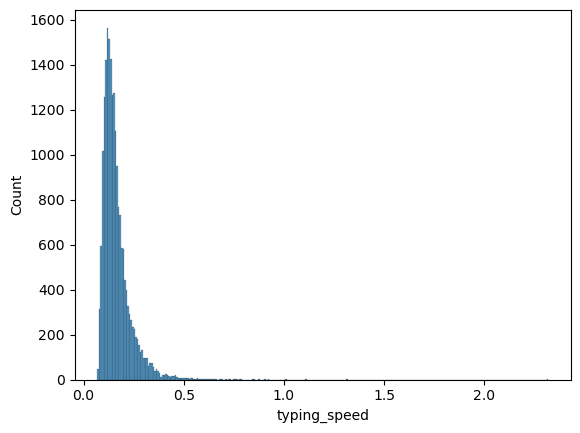

In [7]:
import seaborn as sns #EDA
import matplotlib.pyplot as plt

sns.histplot(df['typing_speed'])
plt.show()

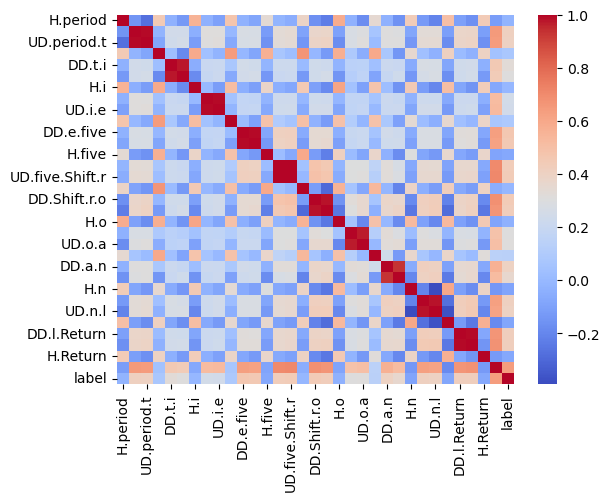

In [8]:
sns.heatmap(df.corr(), cmap='coolwarm') #correlation
plt.show()

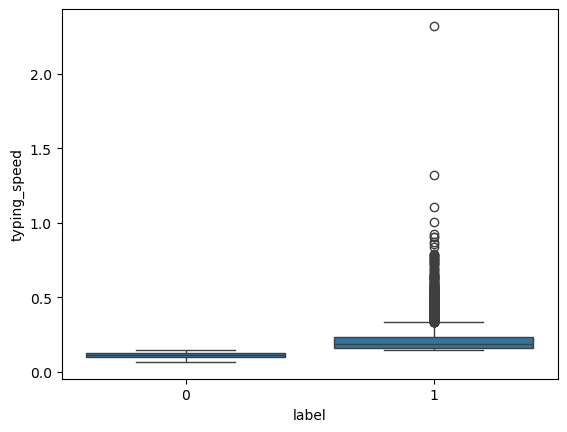

In [9]:
sns.boxplot(x='label', y='typing_speed', data=df) # RELATIONSHIP
plt.show()

In [11]:
X = df.drop('label', axis=1)# feature selection(PCA);split features
y = df['label']

In [13]:
from sklearn.preprocessing import StandardScaler #scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
from sklearn.decomposition import PCA #pca

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

In [16]:
from sklearn.model_selection import train_test_split #train-test-split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.linear_model import LogisticRegression #logistic regression

lr = LogisticRegression()
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
from sklearn.neighbors import KNeighborsClassifier #KNN

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [19]:
from sklearn.svm import SVC #SVM

svm_linear = SVC(kernel='linear')
svm_rbf = SVC(kernel='rbf')
svm_poly = SVC(kernel='poly')

svm_linear.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)
svm_poly.fit(X_train, y_train)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [20]:
from sklearn.metrics import accuracy_score, classification_report #evaluation

def evaluate(model, name):
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

In [21]:
evaluate(lr, "Logistic Regression")
evaluate(knn, "KNN")
evaluate(svm_linear, "SVM Linear")
evaluate(svm_rbf, "SVM RBF")
evaluate(svm_poly, "SVM Polynomial")


Logistic Regression
Accuracy: 0.9852941176470589
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2043
           1       0.99      0.98      0.99      2037

    accuracy                           0.99      4080
   macro avg       0.99      0.99      0.99      4080
weighted avg       0.99      0.99      0.99      4080


KNN
Accuracy: 0.9713235294117647
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2043
           1       0.97      0.97      0.97      2037

    accuracy                           0.97      4080
   macro avg       0.97      0.97      0.97      4080
weighted avg       0.97      0.97      0.97      4080


SVM Linear
Accuracy: 0.9855392156862746
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2043
           1       0.99      0.98      0.99      2037

    accuracy                           0.99      4080
   

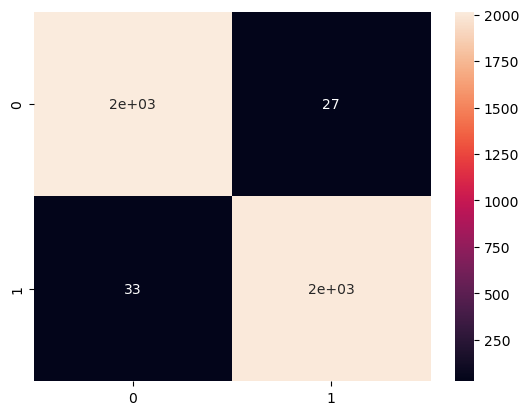

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

sns.heatmap(confusion_matrix(y_test, lr.predict(X_test)), annot=True)
plt.show()